In [2]:
import yfinance as yf
sp500 =  yf.Ticker("^GSPC")


In [3]:
type(sp500)
sp500 = sp500.history(period = "max")


In [4]:
sp500


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,7526.009766,7530.720215,7499.720215,7520.359863,5524250000,0.0,0.0
2026-05-28 00:00:00-04:00,7519.819824,7568.720215,7508.040039,7563.629883,5494860000,0.0,0.0
2026-05-29 00:00:00-04:00,7579.330078,7599.379883,7563.549805,7580.060059,7858290000,0.0,0.0


In [5]:
sp500.index


DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-05-19 00:00:00-04:00', '2026-05-20 00:00:00-04:00',
               '2026-05-21 00:00:00-04:00', '2026-05-22 00:00:00-04:00',
               '2026-05-26 00:00:00-04:00', '2026-05-27 00:00:00-04:00',
               '2026-05-28 00:00:00-04:00', '2026-05-29 00:00:00-04:00',
               '2026-06-01 00:00:00-04:00', '2026-06-02 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24721, freq=None)

<Axes: xlabel='Date'>

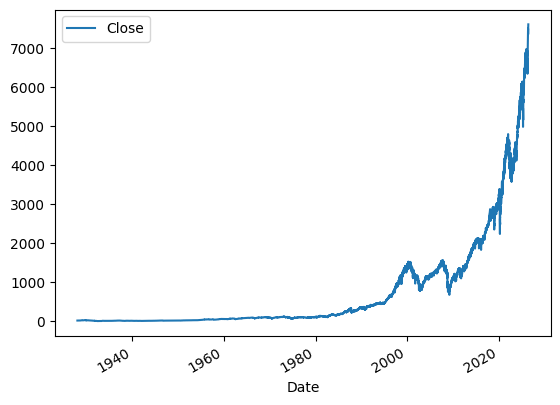

In [6]:
sp500.plot.line(y="Close",use_index= True)


In [7]:
del sp500["Dividends"]
del sp500 ["Stock Splits"]

In [8]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,7526.009766,7530.720215,7499.720215,7520.359863,5524250000,7563.629883
2026-05-28 00:00:00-04:00,7519.819824,7568.720215,7508.040039,7563.629883,5494860000,7580.060059
2026-05-29 00:00:00-04:00,7579.330078,7599.379883,7563.549805,7580.060059,7858290000,7599.959961


In [9]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,7526.009766,7530.720215,7499.720215,7520.359863,5524250000,7563.629883,1
2026-05-28 00:00:00-04:00,7519.819824,7568.720215,7508.040039,7563.629883,5494860000,7580.060059,1
2026-05-29 00:00:00-04:00,7579.330078,7599.379883,7563.549805,7580.060059,7858290000,7599.959961,1


In [10]:
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,7526.009766,7530.720215,7499.720215,7520.359863,5524250000,7563.629883,1
2026-05-28 00:00:00-04:00,7519.819824,7568.720215,7508.040039,7563.629883,5494860000,7580.060059,1
2026-05-29 00:00:00-04:00,7579.330078,7599.379883,7563.549805,7580.060059,7858290000,7599.959961,1


In [15]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 200,min_samples_split = 100,random_state = 1)
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]
predictors = ["Close","Volume","Open","High","Low"]
model.fit(train[predictors], train["Target"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [18]:
from sklearn.metrics import precision_score
import pandas as pd
preds = model.predict(test[predictors])
preds = pd.Series(preds,index = test.index)
preds
precision_score(test["Target"],preds)

0.5853658536585366

<Axes: xlabel='Date'>

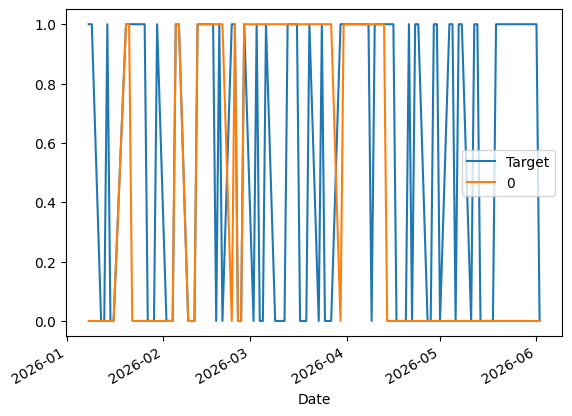

In [21]:
combined = pd.concat([test["Target"],preds],axis = 1)
combined.plot()

In [32]:
def predict(train,test,predictors,model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds,index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds],axis = 1)
    return combined
    

In [33]:
def backtest(data,model,predictors, start= 2500,step = 250):
    all_predictions = []

    for i in range(start,data.shape[0],step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(step + i)].copy()
        predictions = predict(train,test,predictors,model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [34]:
predictions = backtest(sp500,model,predictors)
predictions["Predictions"].value_counts()

Predictions
0    3924
1    2747
Name: count, dtype: int64

In [36]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5293046960320349

In [37]:
predictions["Target"].value_counts() /predictions.shape[0]

Target
1    0.538
0    0.462
Name: count, dtype: float64

In [39]:
horizons = [2,5,60,250,1000]
new_predictions = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()
    ratio_column = f" CLose_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] /rolling_averages["Close"]
    trend_column = f"Trend{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
    new_predictions += [ratio_column,trend_column]

In [40]:
sp500


,Open,High,Low,Close,Volume,Tomorrow,Target,CLose_Ratio_2,Trend2,CLose_Ratio_5,Trend5,CLose_Ratio_60,Trend60,CLose_Ratio_250,Trend250,CLose_Ratio_1000,Trend1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-27 00:00:00-04:00,7526.009766,7530.720215,7499.720215,7520.359863,5524250000,7563.629883,1,1.000082,2.0,1.005620,5.0,1.077621,34.0,1.123966,144.0,1.427684,542.0
2026-05-28 00:00:00-04:00,7519.819824,7568.720215,7508.040039,7563.629883,5494860000,7580.060059,1,1.002869,2.0,1.007885,5.0,1.081891,35.0,1.129318,144.0,1.434955,543.0
2026-05-29 00:00:00-04:00,7579.330078,7599.379883,7563.549805,7580.060059,7858290000,7599.959961,1,1.001085,2.0,1.006471,5.0,1.082408,35.0,1.130644,145.0,1.437144,543.0


In [42]:
model = RandomForestClassifier(n_estimators = 400, min_samples_split = 50, random_state = 1)
def predict(train,test,predictors,model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0
    preds = pd.Series(preds,index = test.index, name = "Predictions")
    combined = pd.concat([test["Target"], preds],axis = 1)
    return combined
predictions = backtest(sp500,model,predictors)
predictions["Predictions"].value_counts()

Predictions
0.0    5569
1.0    1102
Name: count, dtype: int64

In [45]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5190562613430127